Code for efficient coding in Chapter 3 of Computational Foundations of Cognitive Neuroscience (https://gershmanlab.com/textbook/chapter3.pdf).

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.gridspec import GridSpec

In [25]:
# set random seed for reproducibility
np.random.seed(42)

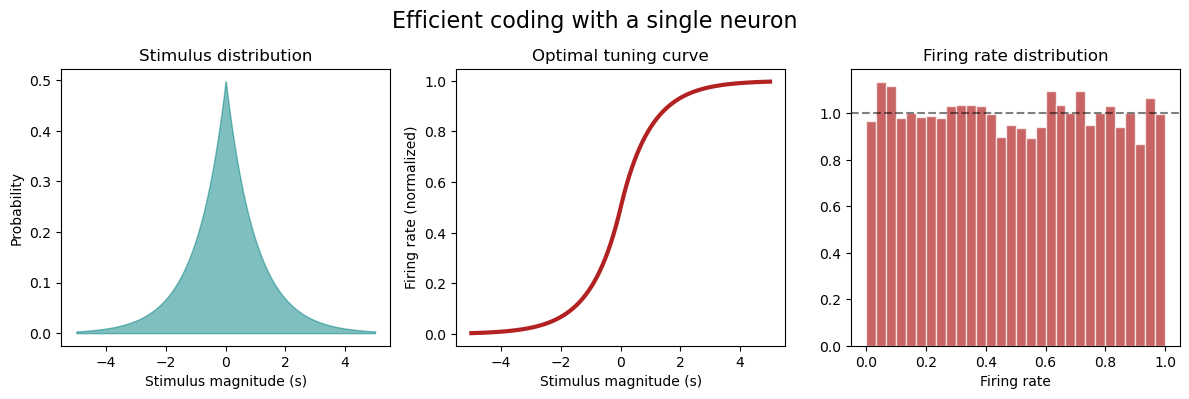

In [26]:
"""
Demonstrates Histogram Equalization (Laughlin, 1981).
A neuron maximizes information by matching its tuning curve to the CDF of the stimulus.
"""

# --- Parameters (Hardcoded for "Natural" Statistics) ---
n_samples = 5000
noise_level = 0.1
x = np.linspace(-5, 5, 1000)

# Using Laplace (Heavy Tail) distribution as it mimics natural image contrast
samples = np.random.laplace(0, 1.0, n_samples)
pdf = stats.laplace.pdf(x, 0, 1.0)
cdf = stats.laplace.cdf(x, 0, 1.0)
tuning_func = lambda s: stats.laplace.cdf(s, 0, 1.0)

# Add noise
noisy_samples = samples + np.random.normal(0, noise_level, n_samples)

# Calculate Responses
response_optimal = tuning_func(noisy_samples)

# --- PLOTTING ---
fig = plt.figure(figsize=(12, 7))
gs = GridSpec(2, 3, figure=fig)
fig.suptitle('Efficient coding with a single neuron', fontsize=16)

# Plot A: Stimulus Distribution (PDF)
ax1 = fig.add_subplot(gs[0, 0])
ax1.fill_between(x, pdf, alpha=0.5, color='teal')
ax1.set_title("Stimulus distribution")
ax1.set_xlabel("Stimulus magnitude (s)")
ax1.set_ylabel("Probability")

# Plot B: Tuning Curve
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(x, cdf, color='firebrick', linewidth=3, label="Optimal (CDF)")
ax2.set_title("Optimal tuning curve")
ax2.set_xlabel("Stimulus magnitude (s)")
ax2.set_ylabel("Firing rate (normalized)")

# Plot C: Response Histogram (Output)
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(response_optimal, bins=30, density=True, color='firebrick', alpha=0.7, edgecolor='white')
ax3.set_title("Firing rate distribution")
ax3.set_xlabel("Firing rate")
ax3.axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label="Target (Uniform)")

plt.tight_layout()
plt.show()

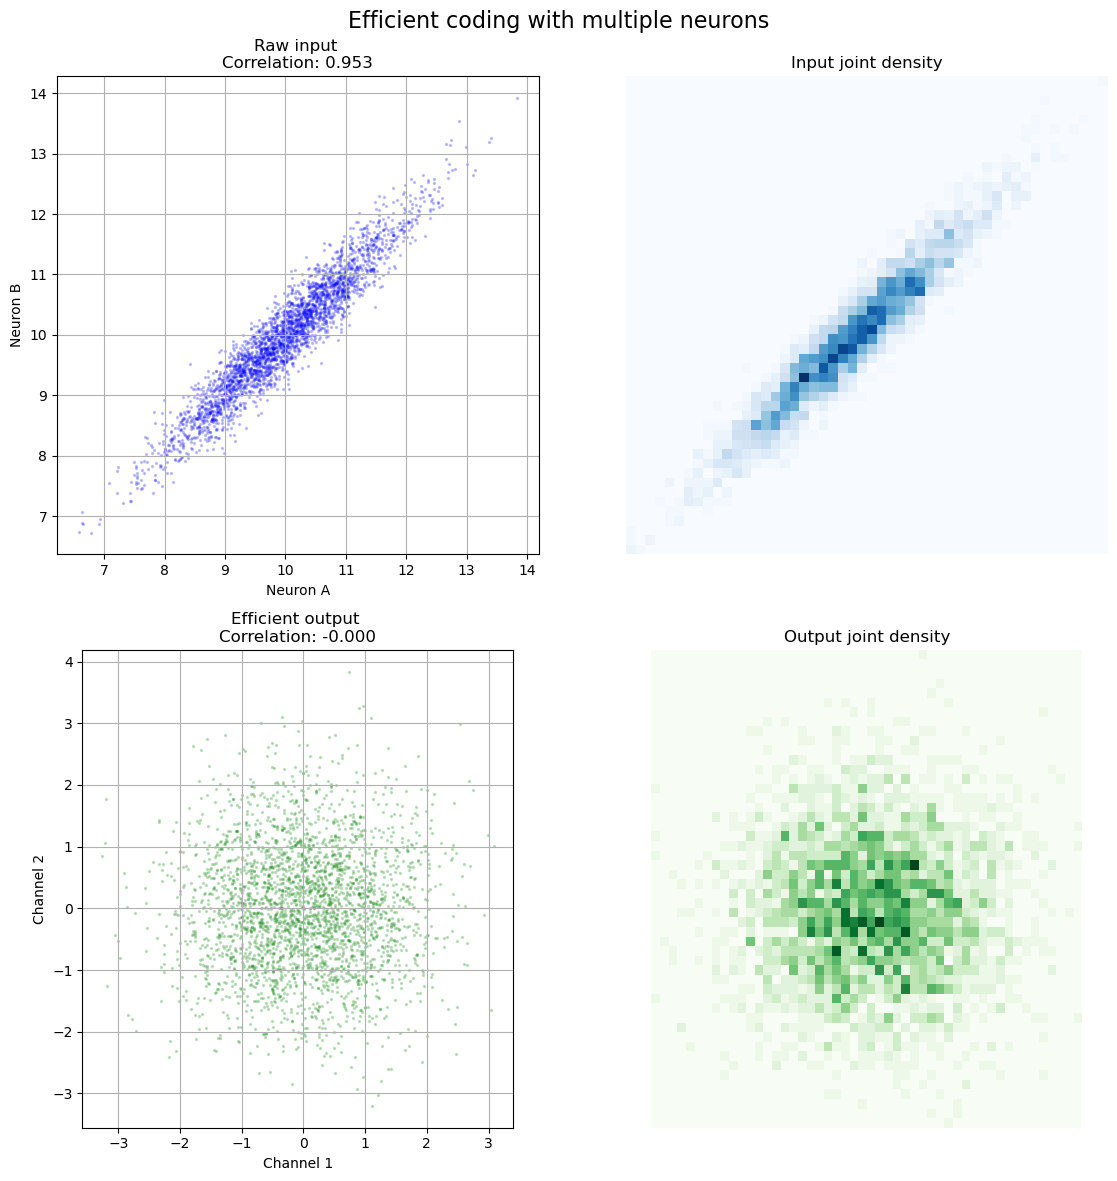

In [27]:
"""
Demonstrates Redundancy Reduction via Whitening.
Decorrelating inputs (like retinal center-surround) maximizes population coding efficiency.
"""

# --- Parameters ---
corr_strength = 0.95
mean = [10, 10]
cov = [[1, corr_strength], [corr_strength, 1]] 

# 1. Generate Correlated Data
data_s = np.random.multivariate_normal(mean, cov, 3000).T
s1, s2 = data_s[0], data_s[1]

# 2. Whitening Transform (Decorrelation)
X = data_s - np.mean(data_s, axis=1, keepdims=True)
sigma = np.cov(X)
evals, evecs = np.linalg.eigh(sigma)
W = evecs @ np.diag(1.0 / np.sqrt(evals)) @ evecs.T

data_r = W @ X
r1, r2 = data_r[0], data_r[1]

# --- PLOTTING ---
fig2 = plt.figure(figsize=(12, 12))
gs2 = GridSpec(2, 2, figure=fig2)
fig2.suptitle('Efficient coding with multiple neurons', fontsize=16)

# Plot A: Raw Inputs
ax_raw = fig2.add_subplot(gs2[0, 0])
ax_raw.scatter(s1, s2, alpha=0.2, s=2, color='blue')
ax_raw.set_title(f"Raw input \nCorrelation: {np.corrcoef(s1, s2)[0,1]:.3f}")
ax_raw.set_xlabel("Neuron A")
ax_raw.set_ylabel("Neuron B")
ax_raw.set_aspect('equal')
ax_raw.grid(True)

# Plot B: Joint Distribution
ax_raw_hist = fig2.add_subplot(gs2[0, 1])
ax_raw_hist.hist2d(s1, s2, bins=50, cmap='Blues')
ax_raw_hist.set_title("Input joint density")
ax_raw_hist.set_aspect('equal')
ax_raw_hist.axis('off')

# Plot C: Efficient Outputs
ax_eff = fig2.add_subplot(gs2[1, 0])
ax_eff.scatter(r1, r2, alpha=0.2, s=2, color='green')
ax_eff.set_title(f"Efficient output \nCorrelation: {np.corrcoef(r1, r2)[0,1]:.3f}")
ax_eff.set_xlabel("Channel 1")
ax_eff.set_ylabel("Channel 2")
ax_eff.set_aspect('equal')
ax_eff.grid(True)

# Plot D: Output Joint Density
ax_eff_hist = fig2.add_subplot(gs2[1, 1])
ax_eff_hist.hist2d(r1, r2, bins=50, cmap='Greens')
ax_eff_hist.set_title("Output joint density")
ax_eff_hist.set_aspect('equal')
ax_eff_hist.axis('off')

plt.tight_layout()
plt.show()